# Notebook 6 — Model Evaluation & Cross-Validation

### Objectives
- K-Fold, Stratified K-Fold, Leave-One-Out cross-validation
- Classification metrics: accuracy, precision, recall, F1, ROC-AUC
- Regression metrics (wealth score formulation): MAE, RMSE, R²
- Learning curves: detect overfitting vs underfitting
- Validation curves: hyperparameter sensitivity
- GridSearchCV: systematic hyperparameter optimisation
- Statistical significance testing between models (paired t-test)
- Final model selection and performance summary


## 1. Setup

In [4]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats

# Sklearn evaluation (Chapter 4 Lab 4.4 reference)
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, KFold, LeaveOneOut,
    learning_curve, validation_curve, GridSearchCV, cross_validate,
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc,
    mean_absolute_error, mean_squared_error, r2_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree  import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from data_cleaner       import DataCleaner
from feature_enginner   import FeatureEngineer
from data_preprocesor   import DataPreprocessor
from modeling           import WealthPredictor, ModelEvaluator

COLORS5 = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1565c0']
RS = 42
print("✓ Setup complete")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Setup complete


## 2. Data Pipeline

In [5]:
df_raw   = pd.read_csv('../data/processed/all_waves_cleaned.csv')
df_clean = DataCleaner().fit_transform(df_raw)
df       = FeatureEngineer().engineer_all(df_clean)

dp     = DataPreprocessor()
splits = dp.fit(df)
X_train, X_val, X_test = splits['X_train'], splits['X_val'], splits['X_test']
y_train, y_val, y_test = splits['y_train'], splits['y_val'], splits['y_test']

# Convert 1-5 quintile labels to 0-4 for classifier compatibility (XGBoost etc.)
y_train = y_train - 1
y_val   = y_val - 1
y_test  = y_test - 1

# Combine train+val for CV (standard practice — test set untouched)
X_cv = np.vstack([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])

print(f"Train+Val (for CV): {X_cv.shape}  |  Test (held-out): {X_test.shape}")
print(f"Classes: {sorted(np.unique(y_cv))}")


Train+Val (for CV): (20279, 68)  |  Test (held-out): (5070, 68)
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## 3. Cross-Validation Methods

In [ ]:
# Base model for CV demonstrations
base_rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                                  class_weight='balanced', random_state=RS, n_jobs=-1)

# ── K-Fold Cross-Validation 
kf = KFold(n_splits=5, shuffle=True, random_state=RS)
kf_scores = cross_val_score(base_rf, X_cv, y_cv, cv=kf, scoring='f1_weighted', n_jobs=-1)
print(f"5-Fold CV F1:            {kf_scores}")
print(f"  Mean ± Std:            {kf_scores.mean():.4f} ± {kf_scores.std():.4f}")

# ── Stratified K-Fold (recommended for imbalanced multi-class )
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
skf_scores = cross_val_score(base_rf, X_cv, y_cv, cv=skf, scoring='f1_weighted', n_jobs=-1)
print(f"\n5-Fold Stratified CV F1: {skf_scores}")
print(f"  Mean ± Std:            {skf_scores.mean():.4f} ± {skf_scores.std():.4f}")

# ── Leave-One-Out (on 200-HH subsample for speed)
X_loo, y_loo = X_cv[:200], y_cv[:200]
loo = LeaveOneOut()
loo_scores = cross_val_score(base_rf, X_loo, y_loo, cv=loo,
                              scoring='f1_weighted', n_jobs=-1)
print(f"\nLOO CV F1 (200 HH sample): {loo_scores.mean():.4f} ± {loo_scores.std():.4f}")


5-Fold CV F1:            [0.38086705 0.38265804 0.36879494 0.37818589 0.37789921]
  Mean ± Std:            0.3777 ± 0.0048

5-Fold Stratified CV F1: [0.38622409 0.37644656 0.37695339 0.37862024 0.37317135]
  Mean ± Std:            0.3783 ± 0.0043

LOO CV F1 (200 HH sample): 0.3200 ± 0.4665


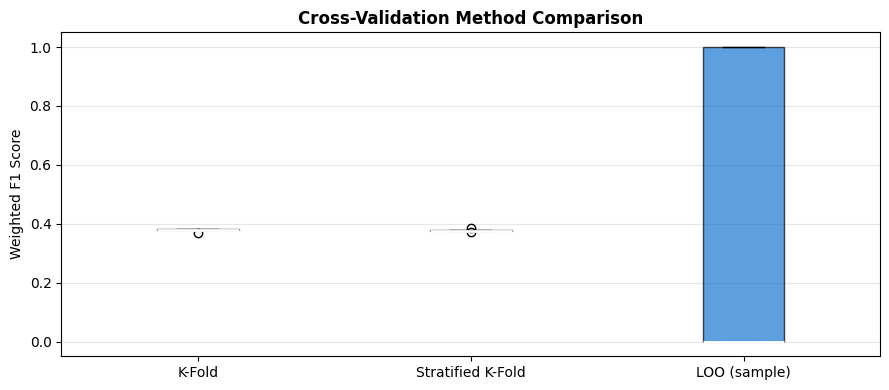

In [23]:
# CV method comparison chart
cv_data = {'K-Fold': kf_scores, 'Stratified K-Fold': skf_scores,
           'LOO (sample)': loo_scores}

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(cv_data.values(), labels=cv_data.keys(), patch_artist=True,
           boxprops=dict(facecolor='#1976D2', alpha=0.7),
           medianprops=dict(color='white', lw=2))
ax.set_ylabel('Weighted F1 Score')
ax.set_title('Cross-Validation Method Comparison', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Multiple Scoring Metrics in CV 

In [8]:
# Compute multiple CV metrics simultaneously
scoring = ['accuracy','f1_weighted','precision_weighted','recall_weighted']
cv_multi = cross_validate(base_rf, X_cv, y_cv, cv=skf,
                           scoring=scoring, n_jobs=-1, return_train_score=True)

metrics_df = pd.DataFrame({
    'Metric':    scoring,
    'Val Mean':  [cv_multi[f'test_{m}'].mean() for m in scoring],
    'Val Std':   [cv_multi[f'test_{m}'].std()  for m in scoring],
    'Train Mean':[cv_multi[f'train_{m}'].mean() for m in scoring],
}).round(4)

print("CV metrics (Stratified 5-fold):")
metrics_df


CV metrics (Stratified 5-fold):


,Metric,Val Mean,Val Std,Train Mean
0,accuracy,0.3895,0.0043,0.6011
1,f1_weighted,0.3783,0.0043,0.6001
2,precision_weighted,0.3790,0.0044,0.6143
3,recall_weighted,0.3895,0.0043,0.6011


## 5. ModelEvaluator - Comprehensive Evaluation 

In [9]:
evaluator = ModelEvaluator()

# Train best model
best_rf = RandomForestClassifier(n_estimators=300, max_depth=12,
                                  class_weight='balanced', random_state=RS, n_jobs=-1)
best_rf.fit(X_train, y_train)

# Comprehensive evaluation (class reference: evaluate_classification)
metrics = evaluator.evaluate_classification(best_rf, X_test, y_test)


── Classification Evaluation ───────────────────────
  Accuracy  : 0.4095
  Precision : 0.3989  (weighted)
  Recall    : 0.4095  (weighted)
  F1 Score  : 0.3990  (weighted)
  Macro F1  : 0.3704

Detailed Classification Report:
              precision    recall  f1-score   support

          Q1       0.38      0.58      0.46       777
          Q2       0.27      0.27      0.27       787
          Q3       0.23      0.19      0.21       897
          Q4       0.35      0.26      0.30      1071
          Q5       0.60      0.63      0.62      1538

    accuracy                           0.41      5070
   macro avg       0.37      0.38      0.37      5070
weighted avg       0.40      0.41      0.40      5070



In [ ]:
# Classification report as DataFrame 
cr_df = evaluator.classification_report_df(y_test, best_rf.predict(X_test))
cr_df


,precision,recall,f1-score,support
Q1 (poorest),0.3821,0.5817,0.4612,777.0000
Q2 (),0.2730,0.2681,0.2705,787.0000
Q3 (),0.2350,0.1873,0.2084,897.0000
Q4 (),0.3485,0.2568,0.2957,1071.0000
Q5 (wealthiest),0.6025,0.6307,0.6163,1538.0000
accuracy,0.4095,0.4095,0.4095,0.4095
macro avg,0.3682,0.3849,0.3704,5070.0000
weighted avg,0.3989,0.4095,0.3990,5070.0000


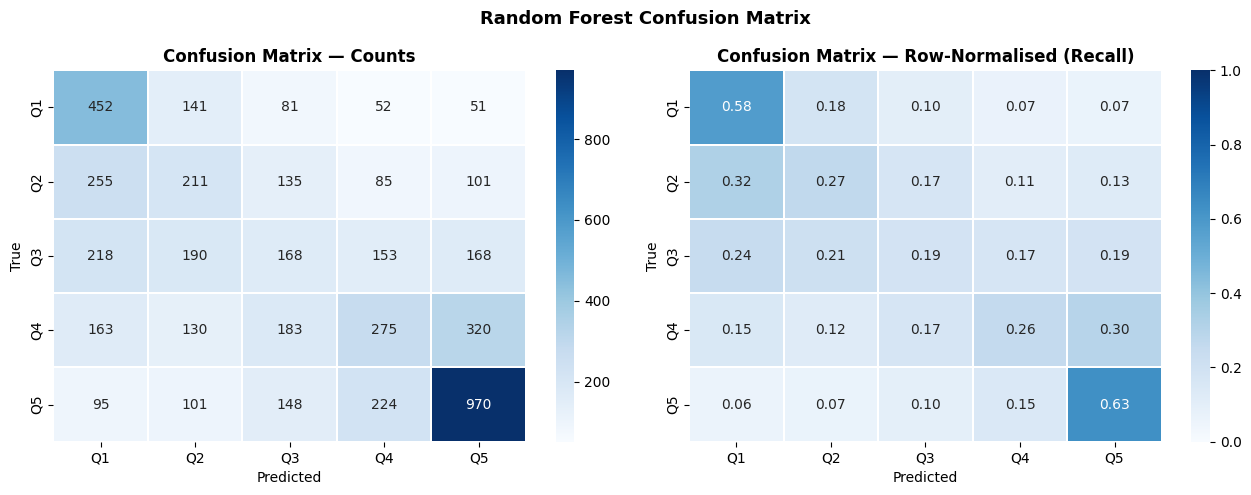

In [11]:
# Labelled confusion matrix
cm_df = evaluator.confusion_matrix_df(y_test, best_rf.predict(X_test))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Absolute counts
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.3, ax=axes[0], cbar=True)
axes[0].set_title('Confusion Matrix — Counts', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# Row-normalised (recall per class)
cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.3, ax=axes[1], cbar=True, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix — Row-Normalised (Recall)',
                  fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle('Random Forest Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/conf_matrix_eval.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. ROC Curves — Multi-Class OvR 

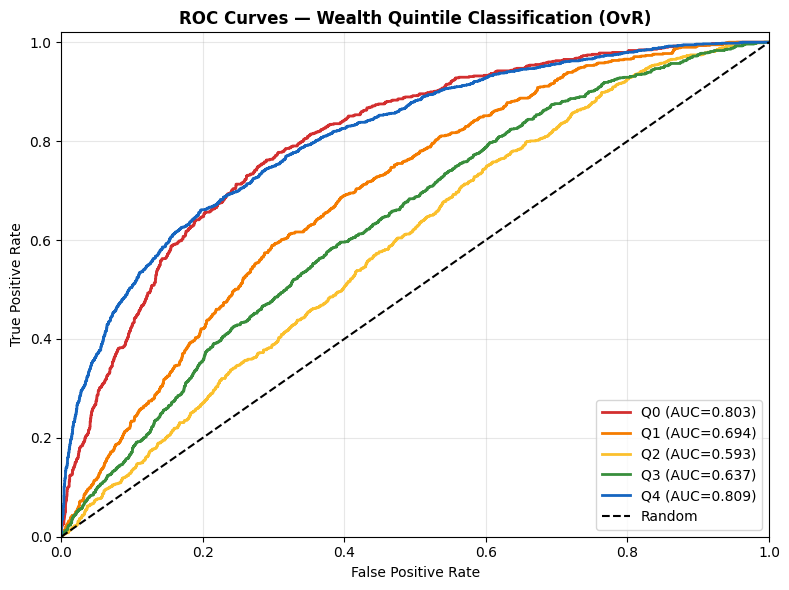

Macro-average AUC: 0.7072


In [12]:
# One-vs-Rest ROC curves for each quintile
classes  = sorted(np.unique(y_test))
y_bin    = label_binarize(y_test, classes=classes)
y_proba  = best_rf.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
for i, (cls, c) in enumerate(zip(classes, COLORS5)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_proba[:,i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=c, lw=2,
            label=f'Q{cls} (AUC={roc_auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Wealth Quintile Classification (OvR)',
             fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Macro-average AUC
macro_auc = roc_auc_score(y_bin, y_proba, average='macro', multi_class='ovr')
print(f"Macro-average AUC: {macro_auc:.4f}")


## 7. Learning Curves — Detect Over/Underfitting 

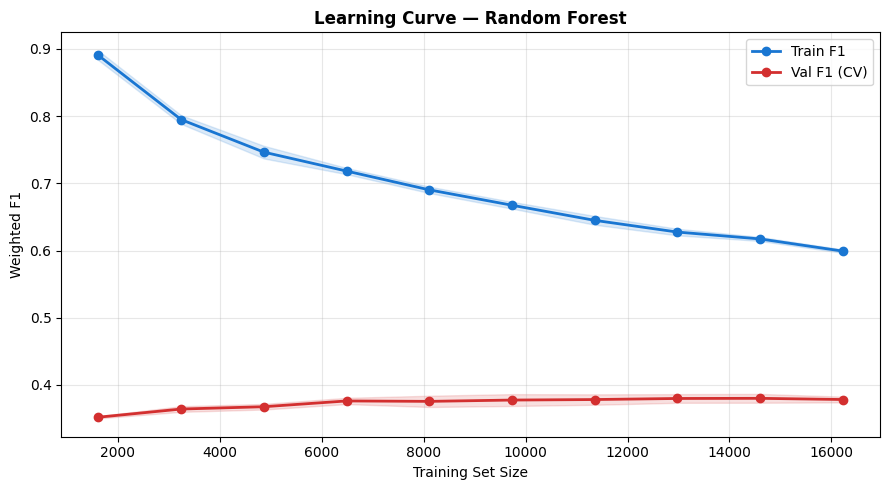

Final Train F1:  0.5991
Final Val F1:    0.3784
Generalisation gap: 0.2208
⚠ Overfitting detected — consider regularisation or less depth


In [ ]:
# Learning curves
train_sizes_frac = np.linspace(0.1, 1.0, 10)
skf_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)

lc_model = RandomForestClassifier(n_estimators=100, max_depth=10,
                                   class_weight='balanced', random_state=RS, n_jobs=-1)
train_sizes, tr_sc, val_sc = learning_curve(
    lc_model, X_cv, y_cv,
    train_sizes=train_sizes_frac, cv=skf_lc,
    scoring='f1_weighted', n_jobs=-1,
)

tr_mean = tr_sc.mean(axis=1); tr_std = tr_sc.std(axis=1)
vl_mean = val_sc.mean(axis=1); vl_std = val_sc.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, tr_mean, 'o-', color='#1976D2', lw=2, label='Train F1')
ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std,
                alpha=0.15, color='#1976D2')
ax.plot(train_sizes, vl_mean, 'o-', color='#d32f2f', lw=2, label='Val F1 (CV)')
ax.fill_between(train_sizes, vl_mean-vl_std, vl_mean+vl_std,
                alpha=0.15, color='#d32f2f')
ax.set_xlabel('Training Set Size'); ax.set_ylabel('Weighted F1')
ax.set_title('Learning Curve — Random Forest', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnose
gap = tr_mean[-1] - vl_mean[-1]
print(f"Final Train F1:  {tr_mean[-1]:.4f}")
print(f"Final Val F1:    {vl_mean[-1]:.4f}")
print(f"Generalisation gap: {gap:.4f}")
if gap > 0.10:
    print("⚠ Overfitting detected — consider regularisation or less depth")
elif vl_mean[-1] < 0.50:
    print("⚠ Underfitting — consider more complex model or more features")
else:
    print("✓ Model generalises well")


## 8. Validation Curves — Hyperparameter Sensitivity 

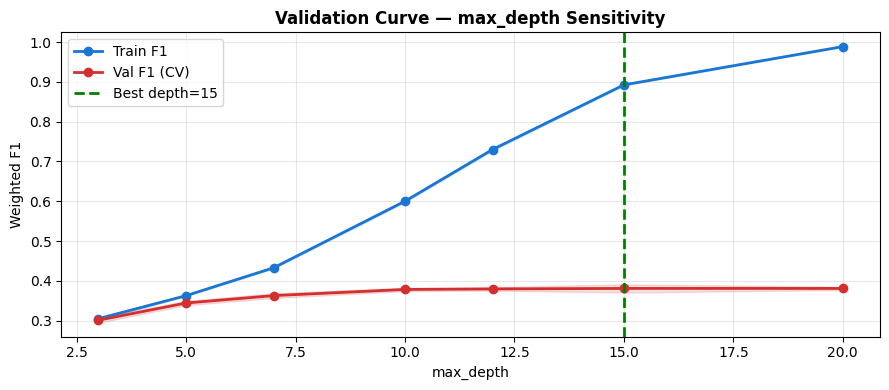

Best max_depth = 15  (Val F1 = 0.3809)


In [ ]:
# Validation curve: max_depth sensitivity 
depth_range = [3, 5, 7, 10, 12, 15, 20]
skf_vc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)

tr_sc_vc, vl_sc_vc = validation_curve(
    RandomForestClassifier(n_estimators=100, class_weight='balanced',
                           random_state=RS, n_jobs=-1),
    X_cv, y_cv,
    param_name='max_depth', param_range=depth_range,
    cv=skf_vc, scoring='f1_weighted', n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depth_range, tr_sc_vc.mean(axis=1), 'o-', color='#1976D2',
        lw=2, label='Train F1')
ax.fill_between(depth_range,
                tr_sc_vc.mean(axis=1) - tr_sc_vc.std(axis=1),
                tr_sc_vc.mean(axis=1) + tr_sc_vc.std(axis=1),
                alpha=0.15, color='#1976D2')
ax.plot(depth_range, vl_sc_vc.mean(axis=1), 'o-', color='#d32f2f',
        lw=2, label='Val F1 (CV)')
ax.fill_between(depth_range,
                vl_sc_vc.mean(axis=1) - vl_sc_vc.std(axis=1),
                vl_sc_vc.mean(axis=1) + vl_sc_vc.std(axis=1),
                alpha=0.15, color='#d32f2f')

best_depth = depth_range[np.argmax(vl_sc_vc.mean(axis=1))]
ax.axvline(best_depth, color='green', ls='--', lw=2,
           label=f'Best depth={best_depth}')
ax.set_xlabel('max_depth'); ax.set_ylabel('Weighted F1')
ax.set_title('Validation Curve — max_depth Sensitivity', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/validation_curve_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best max_depth = {best_depth}  "
      f"(Val F1 = {vl_sc_vc.mean(axis=1).max():.4f})")


## 9. Multi-Model CV Comparison 

In [ ]:
# Compare multiple classifiers with stratified CV 
cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced',
                                               random_state=RS),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, class_weight='balanced',
                                                   random_state=RS),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10,
                                                   class_weight='balanced',
                                                   random_state=RS, n_jobs=-1),
    'KNN (k=7)':           KNeighborsClassifier(n_neighbors=7, weights='distance'),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                                       random_state=RS),
}

model_cv_results = {}
skf_cmp = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
print("Running 5-fold CV for all models…")

for name, model in cv_models.items():
    sc = cross_val_score(model, X_cv, y_cv, cv=skf_cmp,
                         scoring='f1_weighted', n_jobs=-1)
    model_cv_results[name] = sc
    print(f"  {name:<25}: {sc.mean():.4f} ± {sc.std():.4f}")


Running 5-fold CV for all models…


  Logistic Regression      : 0.3783 ± 0.0079
  Decision Tree            : 0.3544 ± 0.0050
  Random Forest            : 0.3783 ± 0.0043
  KNN (k=7)                : 0.3487 ± 0.0056
  Gradient Boosting        : 0.3827 ± 0.0056


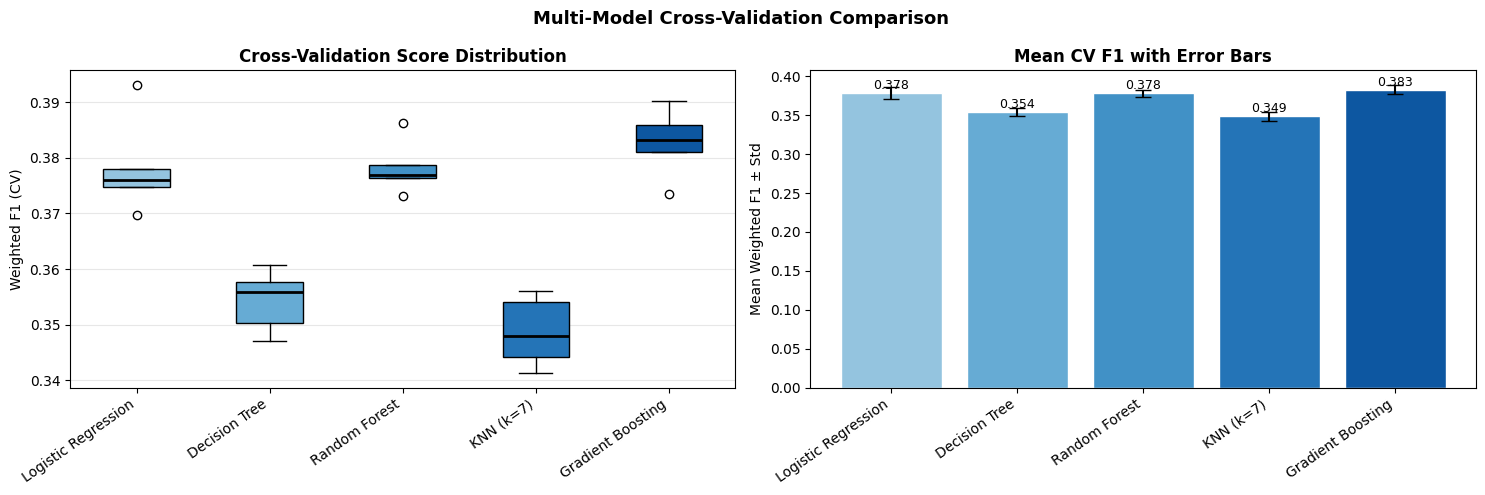

In [ ]:
# Box plot comparison 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

scores_list = list(model_cv_results.values())
names_list  = list(model_cv_results.keys())

# Box plot
bplot = axes[0].boxplot(scores_list, labels=names_list,
                         patch_artist=True,
                         medianprops=dict(color='black', lw=2))
colors_box = plt.cm.Blues(np.linspace(0.4, 0.85, len(names_list)))
for patch, c in zip(bplot['boxes'], colors_box):
    patch.set_facecolor(c)
axes[0].set_xticklabels(names_list, rotation=35, ha='right')
axes[0].set_ylabel('Weighted F1 (CV)')
axes[0].set_title('Cross-Validation Score Distribution', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Mean + Std bar chart
means = [s.mean() for s in scores_list]
stds  = [s.std()  for s in scores_list]
bars  = axes[1].bar(names_list, means, yerr=stds, capsize=6,
                    color=colors_box, edgecolor='white', error_kw={'lw':1.5})
axes[1].set_xticklabels(names_list, rotation=35, ha='right')
axes[1].set_ylabel('Mean Weighted F1 ± Std')
axes[1].set_title('Mean CV F1 with Error Bars', fontweight='bold')
for bar, m in zip(bars, means):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{m:.3f}', ha='center', fontsize=9)

plt.suptitle('Multi-Model Cross-Validation Comparison', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/cv_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Statistical Significance Testing 
Paired t-test to determine if the performance difference between models
is statistically significant.


In [17]:
from scipy.stats import ttest_rel, wilcoxon

best_model_name = max(model_cv_results, key=lambda m: model_cv_results[m].mean())
second_name     = sorted(model_cv_results,
                          key=lambda m: model_cv_results[m].mean())[-2]

best_sc   = model_cv_results[best_model_name]
second_sc = model_cv_results[second_name]

# Paired t-test (Chapter 4 Lab 4.4 Exercise 12)
t_stat, p_val = ttest_rel(best_sc, second_sc)
# Wilcoxon signed-rank test (non-parametric alternative)
w_stat, w_p   = wilcoxon(best_sc, second_sc)

print(f"Statistical comparison: {best_model_name} vs {second_name}")
print("=" * 60)
print(f"  {best_model_name:25} CV F1: {best_sc.mean():.4f} ± {best_sc.std():.4f}")
print(f"  {second_name:25} CV F1: {second_sc.mean():.4f} ± {second_sc.std():.4f}")
print()
print(f"  Paired t-test:              t={t_stat:.3f}  p={p_val:.4f}")
print(f"  Wilcoxon signed-rank:       W={w_stat:.1f}  p={w_p:.4f}")
alpha = 0.05
result = 'SIGNIFICANT DIFFERENCE ✓' if p_val < alpha else 'No significant difference'
print(f"  Conclusion (α={alpha}):        {result}")


Statistical comparison: Gradient Boosting vs Logistic Regression
  Gradient Boosting         CV F1: 0.3827 ± 0.0056
  Logistic Regression       CV F1: 0.3783 ± 0.0079

  Paired t-test:              t=1.366  p=0.2436
  Wilcoxon signed-rank:       W=4.0  p=0.4375
  Conclusion (α=0.05):        No significant difference


## 11. Regression Metrics on Wealth Score 
Treat cons_quint prediction as an ordinal regression problem to compute
MAE and RMSE — interpretable as average quintile prediction error.


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_best = best_rf.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2   = r2_score(y_test, y_pred_best)

print("Regression-style metrics on ordinal wealth quintile:")
print("=" * 50)
print(f"  MAE  (mean quintile error):  {mae:.3f} quintiles")
print(f"  RMSE (root mean sq error):   {rmse:.3f} quintiles")
print(f"  R²   (variance explained):   {r2:.4f}")
print()
print(f"Interpretation: predictions are on average {mae:.2f} quintile(s)")
print(f"away from the true wealth quintile.")


Regression-style metrics on ordinal wealth quintile:
  MAE  (mean quintile error):  1.005 quintiles
  RMSE (root mean sq error):   1.474 quintiles
  R²   (variance explained):   -0.0511

Interpretation: predictions are on average 1.01 quintile(s)
away from the true wealth quintile.


## 12. Final Model Selection Summary

In [19]:
# Load full WealthPredictor results if available, else use cv_models
wp2 = WealthPredictor(random_state=RS)
final_results = wp2.train_evaluate(X_train, y_train, X_test, y_test, cv_folds=5)

print(f"\n{'='*60}")
print(f"FINAL MODEL SELECTION")
print(f"{'='*60}")
print(f"Best model:       {wp2.best_name_}")
best_row = final_results.iloc[0]
print(f"Test accuracy:    {best_row['accuracy']:.4f}")
print(f"Test weighted F1: {best_row['weighted_f1']:.4f}")
print(f"Test macro F1:    {best_row['macro_f1']:.4f}")
print(f"CV F1 mean:       {best_row['cv_f1_mean']:.4f} ± {best_row['cv_f1_std']:.4f}")
print(f"\nAll model results:")
final_results



✓ Best model: Random Forest (weighted F1 = 0.3992)

FINAL MODEL SELECTION
Best model:       Random Forest
Test accuracy:    0.4081
Test weighted F1: 0.3992
Test macro F1:    0.3714
CV F1 mean:       0.3839 ± 0.0057

All model results:


,model,accuracy,precision,recall,weighted_f1,macro_f1,cv_f1_mean,cv_f1_std
0,Random Forest,0.4081,0.4008,0.4081,0.3992,0.3714,0.3839,0.0057
1,LightGBM,0.4037,0.3976,0.4037,0.3973,0.3703,0.3882,0.0037
2,Logistic Regression,0.3986,0.3863,0.3986,0.3876,0.3593,0.3775,0.0049
3,XGBoost,0.4132,0.3761,0.4132,0.3854,0.3551,0.3831,0.0067
4,Gradient Boosting,0.4063,0.3710,0.4063,0.3800,0.3498,0.3815,0.0059
5,Decision Tree,0.3501,0.3706,0.3501,0.3567,0.3343,0.3447,0.0042
6,KNN,0.3588,0.3425,0.3588,0.3489,0.3193,0.3509,0.0063
7,Naive Bayes,0.3325,0.3639,0.3325,0.3181,0.2940,0.3143,0.0030
8,AdaBoost,0.3669,0.2369,0.3669,0.2855,0.2402,0.2805,0.0030


In [20]:
# Cross-validation evaluation report 
evaluator2 = ModelEvaluator()
cv_report  = evaluator2.cross_validate(
    wp2.best_model_, X_cv, y_cv, cv_folds=5, scoring='f1_weighted'
)
cv_report



CV (5-fold) f1_weighted: 0.3832 ± 0.0079


,fold,f1_weighted
0,1,0.3984
1,2,0.3818
2,3,0.3812
3,4,0.3782
4,5,0.3762
5,MEAN,0.3832
6,STD,0.0079


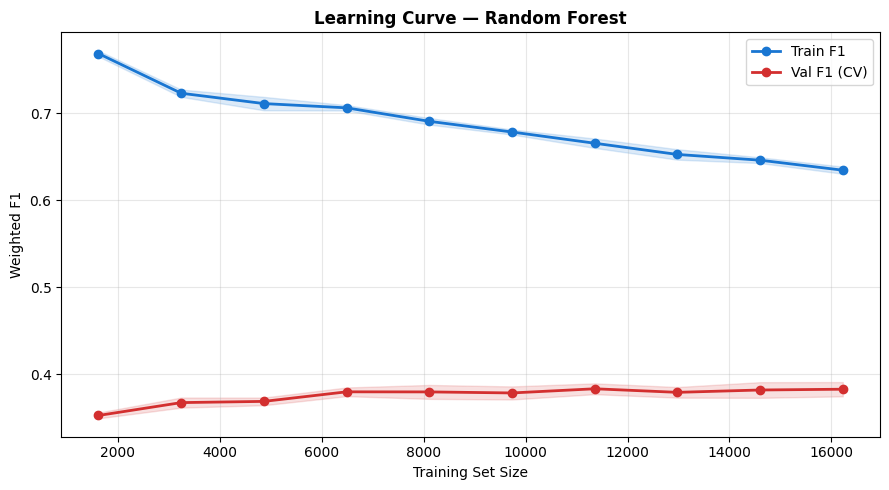

In [21]:
# Learning curve for best model
lc_df = evaluator2.learning_curve_analysis(
    wp2.best_model_, X_cv, y_cv, cv_folds=5
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lc_df['train_size'], lc_df['train_score'], 'o-',
        color='#1976D2', lw=2, label='Train F1')
ax.fill_between(lc_df['train_size'],
                lc_df['train_score']-lc_df['train_std'],
                lc_df['train_score']+lc_df['train_std'],
                alpha=0.15, color='#1976D2')
ax.plot(lc_df['train_size'], lc_df['val_score'], 'o-',
        color='#d32f2f', lw=2, label='Val F1 (CV)')
ax.fill_between(lc_df['train_size'],
                lc_df['val_score']-lc_df['val_std'],
                lc_df['val_score']+lc_df['val_std'],
                alpha=0.15, color='#d32f2f')
ax.set_xlabel('Training Set Size'); ax.set_ylabel('Weighted F1')
ax.set_title(f'Learning Curve — {wp2.best_name_}', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/final_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
# Save final evaluation report
eval_summary = pd.DataFrame([{
    'best_model':    wp2.best_name_,
    'test_accuracy': final_results.iloc[0]['accuracy'],
    'test_f1_weighted': final_results.iloc[0]['weighted_f1'],
    'test_f1_macro': final_results.iloc[0]['macro_f1'],
    'cv_f1_mean':    final_results.iloc[0]['cv_f1_mean'],
    'cv_f1_std':     final_results.iloc[0]['cv_f1_std'],
    'mae_quintile':  mae,
    'rmse_quintile': rmse,
}])
eval_summary.to_csv('../reports/final_evaluation_summary.csv', index=False)
wp2.save('../models')
print("✓ Final models and evaluation summary saved.")
eval_summary.T


Best model saved → ..\models\best_model.pkl
✓ Final models and evaluation summary saved.


,0
best_model,Random Forest
test_accuracy,0.4081
test_f1_weighted,0.3992
test_f1_macro,0.3714
cv_f1_mean,0.3839
cv_f1_std,0.0057
mae_quintile,1.005128
rmse_quintile,1.473634
